# Sales Prediction using Machine Learning

## Objective
The objective of this project is to predict product sales based on advertising expenditures on TV, Radio, and Newspaper using Machine Learning.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [6]:
df.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [7]:
df.drop(columns=["Unnamed: 0"], inplace=True)

In [8]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


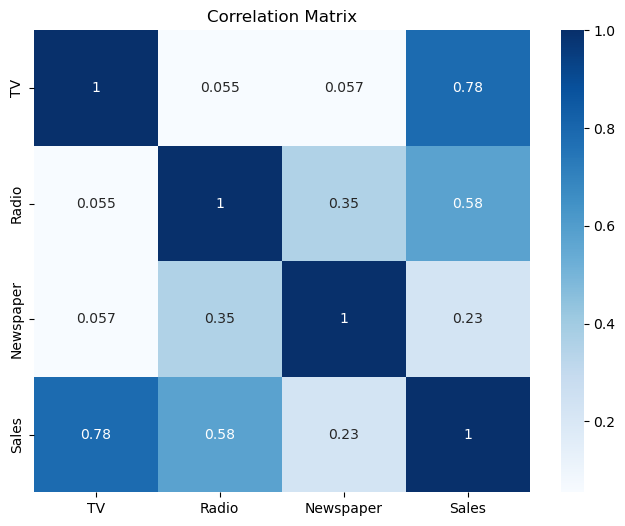

In [11]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),annot=True,cmap="Blues")

plt.title("Correlation Matrix")

plt.show()

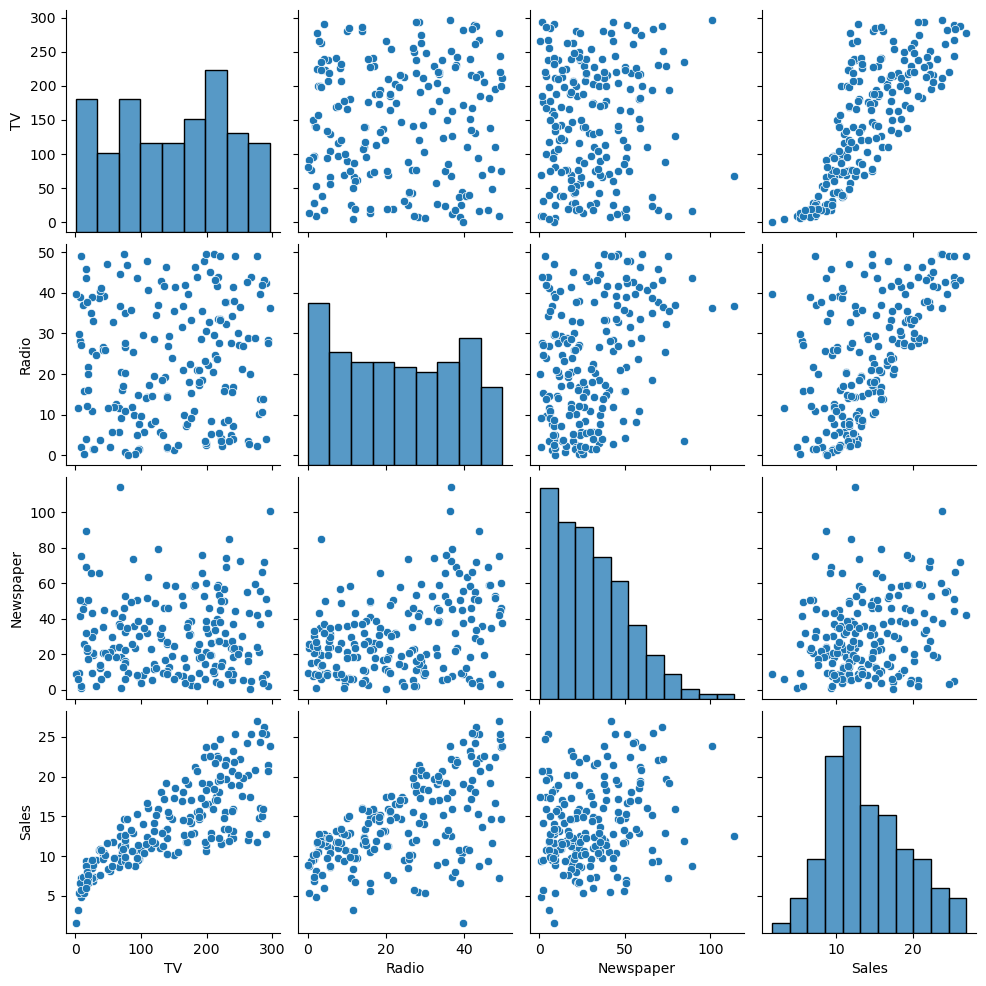

In [12]:
sns.pairplot(df)

plt.show()

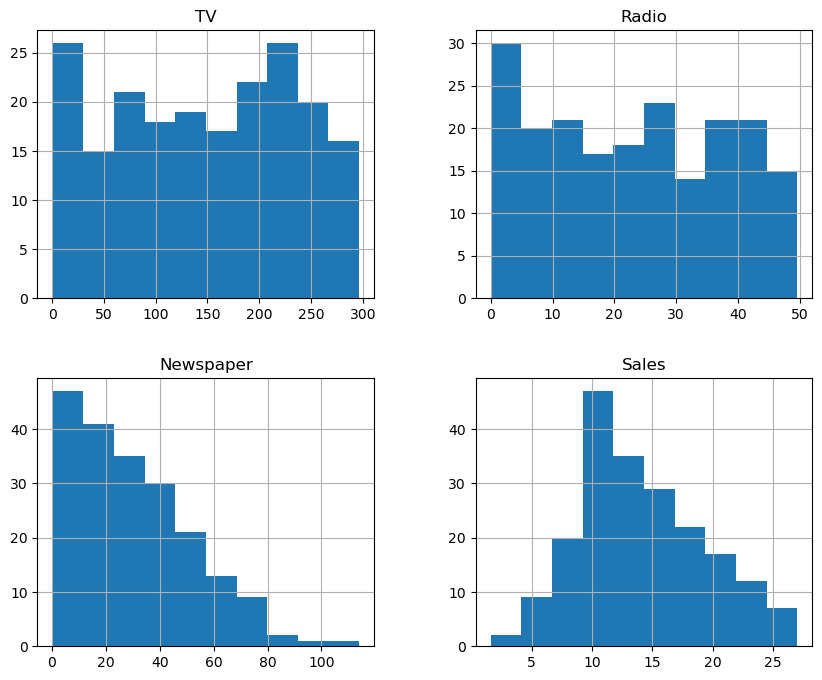

In [13]:
df.hist(figsize=(10,8))

plt.show()

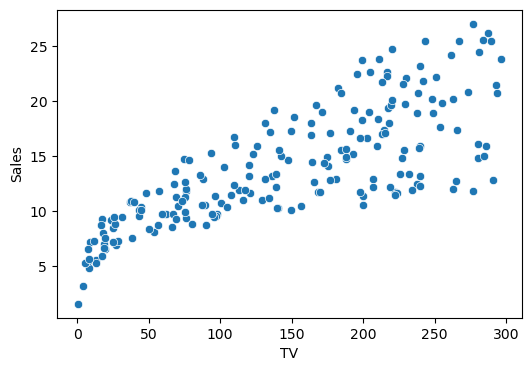

In [14]:
plt.figure(figsize=(6,4))

sns.scatterplot(data=df,x="TV",y="Sales")

plt.show()

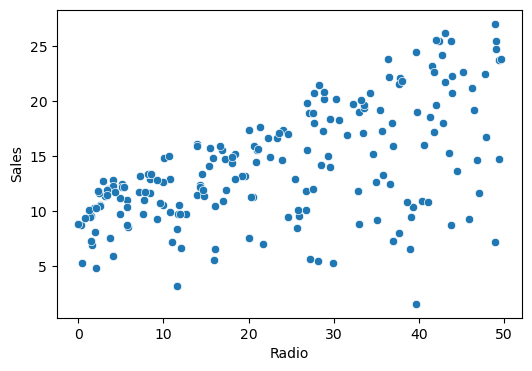

In [15]:
plt.figure(figsize=(6,4))

sns.scatterplot(data=df,x="Radio",y="Sales")

plt.show()

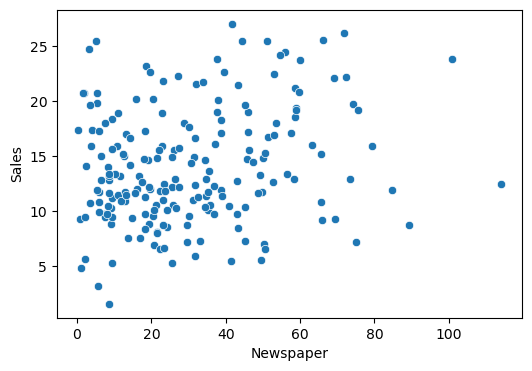

In [16]:
plt.figure(figsize=(6,4))

sns.scatterplot(data=df,x="Newspaper",y="Sales")

plt.show()

In [17]:
df["Total_Ads"] = df["TV"] + df["Radio"] + df["Newspaper"]

A new feature Total_Ads is created by adding TV, Radio and Newspaper advertising budgets

In [18]:
df.head()

,TV,Radio,Newspaper,Sales,Total_Ads
0,230.1,37.8,69.2,22.1,337.1
1,44.5,39.3,45.1,10.4,128.9
2,17.2,45.9,69.3,9.3,132.4
3,151.5,41.3,58.5,18.5,251.3
4,180.8,10.8,58.4,12.9,250.0


In [19]:
X = df.drop("Sales",axis=1)

y = df["Sales"]

In [20]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
model = LinearRegression()

model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [22]:
prediction = model.predict(X_test)

In [23]:
mae = mean_absolute_error(y_test,prediction)

mse = mean_squared_error(y_test,prediction)

rmse = np.sqrt(mse)

r2 = r2_score(y_test,prediction)

print("MAE :",mae)

print("RMSE :",rmse)

print("R2 Score :",r2)

MAE : 1.4607567168117606
RMSE : 1.7815996615334504
R2 Score : 0.899438024100912


In [24]:
result = pd.DataFrame({
    "Actual":y_test,
    "Predicted":prediction
})

result.head(10)

,Actual,Predicted
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373
115,12.6,13.105592
69,22.3,21.057192
170,8.4,7.461010
174,11.5,13.606346
45,14.9,15.155070


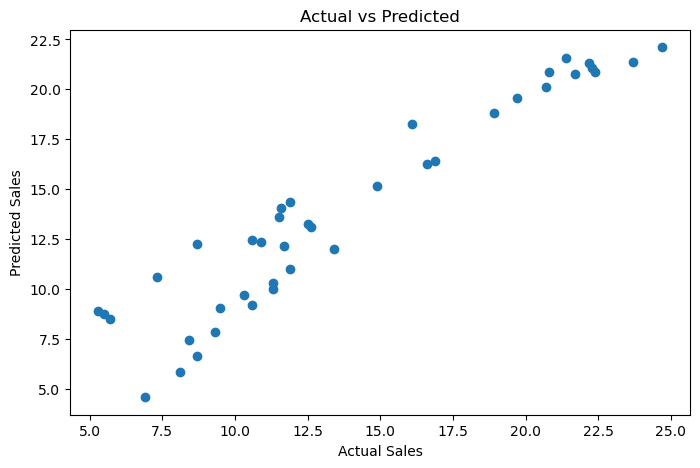

In [25]:
plt.figure(figsize=(8,5))

plt.scatter(y_test,prediction)

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted")

plt.show()

## Feature Selection using Correlation
We can check which advertising features have stronger relationship with Sales.

In [26]:
correlation = df.corr()
print(correlation['Sales'].sort_values(ascending=False))

Sales        1.000000
Total_Ads    0.867712
TV           0.782224
Radio        0.576223
Newspaper    0.228299
Name: Sales, dtype: float64


## Regression Coefficients
These values show how much Sales changes when one advertising feature increases by 1 unit while others remain constant.

In [27]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
print(coefficients)
print('Intercept:', model.intercept_)

     Feature  Coefficient
0         TV    -0.014442
1      Radio     0.130024
2  Newspaper    -0.056410
3  Total_Ads     0.059171
Intercept: 2.9790673381226256


## Feature Importance (Using Coefficients)

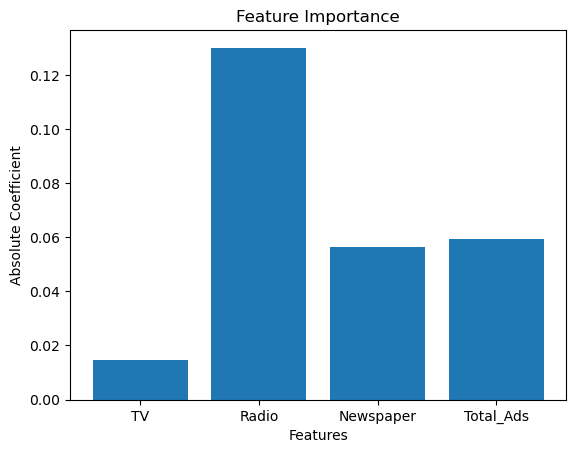

In [28]:
importance = abs(coefficients['Coefficient'])
plt.bar(coefficients['Feature'], importance)
plt.title('Feature Importance')
plt.xlabel('Features')
plt.ylabel('Absolute Coefficient')
plt.show()

## Future Sales Prediction

In [29]:
future_budget = pd.DataFrame({'TV':[150], 'Radio':[25], 'Newspaper':[20]})

future_budget['Total_Ads'] = future_budget['TV'] + future_budget['Radio'] + future_budget['Newspaper']

predicted_sales = model.predict(future_budget)
print('Predicted Sales:',(round(predicted_sales[0],2)))

Predicted Sales: 14.47


## Model Performance Interpretation
- Lower MAE and RMSE indicate smaller prediction errors.
- Higher R² means the model explains more variation in Sales.
- A value closer to 1 for R² indicates a better model.

## Advertising Impact Analysis
Compare the regression coefficients and feature importance chart. The feature with the largest positive coefficient has the strongest impact on Sales.

## Business Recommendations
- Invest more in the advertising channel with the highest impact.
- Monitor advertising budget regularly.
- Reduce spending on low-impact channels if needed.
- Use the model to estimate future sales before planning campaigns.

## Final Conclusion
The Linear Regression model successfully predicted product sales using advertising budgets.
Among all advertising platforms, TV advertising showed the highest impact on sales, followed by Radio.
This project demonstrates how machine learning can help businesses make better marketing decisions.